In [2]:
from datasets import load_dataset
dataset = load_dataset("edinburghcstr/ami", "ihm")


Using the latest cached version of the module from /Users/khumachbayramova/.cache/huggingface/modules/datasets_modules/datasets/edinburghcstr--ami/0d128d0aa8145d0f16f3d5b4da86c5d5759dbe9e8f947fda04b25edb56442bd5 (last modified on Fri Jan 10 20:25:58 2025) since it couldn't be found locally at edinburghcstr/ami., or remotely on the Hugging Face Hub.
Found cached dataset ami (/Users/khumachbayramova/.cache/huggingface/datasets/edinburghcstr___ami/ihm/0.0.0/0d128d0aa8145d0f16f3d5b4da86c5d5759dbe9e8f947fda04b25edb56442bd5)


  0%|          | 0/3 [00:00<?, ?it/s]

In [3]:
dataset

DatasetDict({
    train: Dataset({
        features: ['meeting_id', 'audio_id', 'text', 'audio', 'begin_time', 'end_time', 'microphone_id', 'speaker_id'],
        num_rows: 108502
    })
    validation: Dataset({
        features: ['meeting_id', 'audio_id', 'text', 'audio', 'begin_time', 'end_time', 'microphone_id', 'speaker_id'],
        num_rows: 13098
    })
    test: Dataset({
        features: ['meeting_id', 'audio_id', 'text', 'audio', 'begin_time', 'end_time', 'microphone_id', 'speaker_id'],
        num_rows: 12643
    })
})

In [2]:
dataset["train"][1]

{'meeting_id': 'EN2001a',
 'audio_id': 'AMI_EN2001a_H00_MEE068_0414915_0415078',
 'text': "I'VE GOTTEN MM HARDLY ANY",
 'audio': {'path': '/Users/khumachbayramova/.cache/huggingface/datasets/downloads/extracted/809f6afa4b0e9a06aa2dd4cdfcee93854a324b73879d8c98bf1c291710ecce7c/EN2001a/train_ami_en2001a_h00_mee068_0414915_0415078.wav',
  'array': array([-5.18798828e-04,  1.22070312e-04,  1.22070312e-04, ...,
          9.15527344e-05, -1.83105469e-04, -3.35693359e-04]),
  'sampling_rate': 16000},
 'begin_time': 4149.14990234375,
 'end_time': 4150.77978515625,
 'microphone_id': 'H00',
 'speaker_id': 'MEE068'}

In [4]:
# Статистика по AMI датасету
import pandas as pd
from collections import defaultdict, Counter
import numpy as np

def analyze_ami_dataset(dataset):
    """Анализ статистики AMI датасета"""
    
    print("="*80)
    print("СТАТИСТИКА AMI ДАТАСЕТА")
    print("="*80)
    
    # Общая статистика по сплитам
    print("\n📊 ОБЩАЯ СТАТИСТИКА ПО СПЛИТАМ:")
    for split_name, split_data in dataset.items():
        print(f"  {split_name.upper()}:")
        print(f"    - Количество сэмплов: {len(split_data):,}")
        print(f"    - Количество встреч: {len(set(sample['meeting_id'] for sample in split_data))}")
        print(f"    - Уникальные спикеры: {len(set(sample['speaker_id'] for sample in split_data))}")
    
    # Анализ по встречам
    print(f"\n🏢 АНАЛИЗ ПО ВСТРЕЧАМ:")
    
    # Собираем данные по всем сплитам
    all_meetings = defaultdict(list)
    all_speakers = set()
    all_durations = []
    all_audio_lengths = []
    
    for split_name, split_data in dataset.items():
        for sample in split_data:
            meeting_id = sample['meeting_id']
            speaker_id = sample['speaker_id']
            duration = sample['end_time'] - sample['begin_time']
            audio_length = len(sample['audio']['array'])
            
            all_meetings[meeting_id].append({
                'split': split_name,
                'speaker_id': speaker_id,
                'duration': duration,
                'audio_length': audio_length,
                'begin_time': sample['begin_time'],
                'end_time': sample['end_time']
            })
            all_speakers.add(speaker_id)
            all_durations.append(duration)
            all_audio_lengths.append(audio_length)
    
    # Статистика по встречам
    meeting_stats = []
    for meeting_id, samples in all_meetings.items():
        speakers = set(s['speaker_id'] for s in samples)
        total_duration = sum(s['duration'] for s in samples)
        splits = set(s['split'] for s in samples)
        
        meeting_stats.append({
            'meeting_id': meeting_id,
            'num_samples': len(samples),
            'num_speakers': len(speakers),
            'speakers': sorted(speakers),
            'total_duration': total_duration,
            'splits': sorted(splits)
        })
    
    # Сортируем по количеству сэмплов
    meeting_stats.sort(key=lambda x: x['num_samples'], reverse=True)
    
    print(f"  - Всего встреч: {len(meeting_stats)}")
    print(f"  - Всего уникальных спикеров: {len(all_speakers)}")
    
    # Топ-10 встреч по количеству сэмплов
    print(f"\n  ТОП-10 ВСТРЕЧ ПО КОЛИЧЕСТВУ СЭМПЛОВ:")
    for i, meeting in enumerate(meeting_stats[:10]):
        print(f"    {i+1:2d}. {meeting['meeting_id']}: {meeting['num_samples']:4d} сэмплов, "
              f"{meeting['num_speakers']} спикеров, {meeting['total_duration']:6.1f}с")
    
    # Статистика по длительности аудио
    print(f"\n⏱️ СТАТИСТИКА ПО ДЛИТЕЛЬНОСТИ АУДИО:")
    print(f"  - Минимальная длительность: {min(all_durations):.2f} секунд")
    print(f"  - Максимальная длительность: {max(all_durations):.2f} секунд")
    print(f"  - Средняя длительность: {np.mean(all_durations):.2f} секунд")
    print(f"  - Медианная длительность: {np.median(all_durations):.2f} секунд")
    print(f"  - Стандартное отклонение: {np.std(all_durations):.2f} секунд")
    
    # Статистика по длине аудио массивов
    print(f"\n🎵 СТАТИСТИКА ПО ДЛИНЕ АУДИО МАССИВОВ:")
    print(f"  - Минимальная длина: {min(all_audio_lengths):,} сэмплов")
    print(f"  - Максимальная длина: {max(all_audio_lengths):,} сэмплов")
    print(f"  - Средняя длина: {np.mean(all_audio_lengths):,.0f} сэмплов")
    print(f"  - Медианная длина: {np.median(all_audio_lengths):,.0f} сэмплов")
    
    # Распределение по количеству спикеров в встречах
    print(f"\n👥 РАСПРЕДЕЛЕНИЕ ПО КОЛИЧЕСТВУ СПИКЕРОВ В ВСТРЕЧАХ:")
    speaker_counts = Counter(meeting['num_speakers'] for meeting in meeting_stats)
    for num_speakers in sorted(speaker_counts.keys()):
        count = speaker_counts[num_speakers]
        print(f"  - {num_speakers} спикеров: {count} встреч ({count/len(meeting_stats)*100:.1f}%)")
    
    # Статистика по спикерам
    print(f"\n🗣️ СТАТИСТИКА ПО СПИКЕРАМ:")
    speaker_sample_counts = Counter()
    speaker_duration_counts = defaultdict(float)
    
    for meeting_id, samples in all_meetings.items():
        for sample in samples:
            speaker_sample_counts[sample['speaker_id']] += 1
            speaker_duration_counts[sample['speaker_id']] += sample['duration']
    
    # Топ-10 спикеров по количеству сэмплов
    print(f"  ТОП-10 СПИКЕРОВ ПО КОЛИЧЕСТВУ СЭМПЛОВ:")
    for i, (speaker_id, count) in enumerate(speaker_sample_counts.most_common(10)):
        duration = speaker_duration_counts[speaker_id]
        print(f"    {i+1:2d}. {speaker_id}: {count:4d} сэмплов, {duration:6.1f}с")
    
    # Статистика по микрофонам
    print(f"\n🎤 СТАТИСТИКА ПО МИКРОФОНАМ:")
    mic_counts = Counter()
    for split_name, split_data in dataset.items():
        for sample in split_data:
            mic_counts[sample['microphone_id']] += 1
    
    for mic_id, count in mic_counts.most_common():
        print(f"  - {mic_id}: {count:,} сэмплов")
    
    # Временная статистика
    print(f"\n⏰ ВРЕМЕННАЯ СТАТИСТИКА:")
    all_begin_times = []
    all_end_times = []
    
    for split_name, split_data in dataset.items():
        for sample in split_data:
            all_begin_times.append(sample['begin_time'])
            all_end_times.append(sample['end_time'])
    
    print(f"  - Минимальное время начала: {min(all_begin_times):.1f} секунд")
    print(f"  - Максимальное время окончания: {max(all_end_times):.1f} секунд")
    print(f"  - Общий временной диапазон: {max(all_end_times) - min(all_begin_times):.1f} секунд")
    
    return {
        'meeting_stats': meeting_stats,
        'all_speakers': all_speakers,
        'all_durations': all_durations,
        'all_audio_lengths': all_audio_lengths,
        'speaker_sample_counts': speaker_sample_counts,
        'speaker_duration_counts': speaker_duration_counts,
        'mic_counts': mic_counts
    }

# Запускаем анализ
stats = analyze_ami_dataset(dataset)


СТАТИСТИКА AMI ДАТАСЕТА

📊 ОБЩАЯ СТАТИСТИКА ПО СПЛИТАМ:
  TRAIN:
    - Количество сэмплов: 108,502
    - Количество встреч: 137
    - Уникальные спикеры: 155
  VALIDATION:
    - Количество сэмплов: 13,098
    - Количество встреч: 18
    - Уникальные спикеры: 21
  TEST:
    - Количество сэмплов: 12,643
    - Количество встреч: 16
    - Уникальные спикеры: 16

🏢 АНАЛИЗ ПО ВСТРЕЧАМ:
  - Всего встреч: 171
  - Всего уникальных спикеров: 190

  ТОП-10 ВСТРЕЧ ПО КОЛИЧЕСТВУ СЭМПЛОВ:
     1. EN2009d: 2419 сэмплов, 4 спикеров, 5577.3с
     2. TS3006d: 1728 сэмплов, 4 спикеров, 3273.3с
     3. EN2001a: 1675 сэмплов, 5 спикеров, 4926.5с
     4. IN1013: 1656 сэмплов, 4 спикеров, 3898.5с
     5. TS3005d: 1636 сэмплов, 4 спикеров, 2981.0с
     6. EN2005a: 1614 сэмплов, 4 спикеров, 5542.4с
     7. EN2006a: 1590 сэмплов, 4 спикеров, 2860.3с
     8. IN1016: 1533 сэмплов, 4 спикеров, 4219.2с
     9. EN2002c: 1469 сэмплов, 3 спикеров, 3387.3с
    10. EN2006b: 1445 сэмплов, 4 спикеров, 2539.8с

⏱️ СТАТИСТИ

In [3]:
# Подробный анализ сбалансированности AMI датасета
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import Counter, defaultdict
import numpy as np

def comprehensive_dataset_analysis(dataset):
    """
    Комплексный анализ сбалансированности AMI датасета
    """
    print("="*80)
    print("📊 КОМПЛЕКСНЫЙ АНАЛИЗ СБАЛАНСИРОВАННОСТИ AMI ДАТАСЕТА")
    print("="*80)
    
    # Собираем данные по всем сплитам
    all_data = []
    for split_name, split_data in dataset.items():
        for sample in split_data:
            all_data.append({
                'split': split_name,
                'meeting_id': sample['meeting_id'],
                'speaker_id': sample['speaker_id'],
                'microphone_id': sample['microphone_id'],
                'duration': sample['end_time'] - sample['begin_time'],
                'begin_time': sample['begin_time'],
                'end_time': sample['end_time'],
                'audio_length': len(sample['audio']['array'])
            })
    
    df = pd.DataFrame(all_data)
    
    # 1. Анализ распределения по сплитам
    print("\n📈 1. РАСПРЕДЕЛЕНИЕ ПО СПЛИТАМ:")
    split_stats = df.groupby('split').agg({
        'meeting_id': 'nunique',
        'speaker_id': 'nunique', 
        'duration': ['count', 'sum', 'mean'],
        'audio_length': 'sum'
    }).round(2)
    
    print(split_stats)
    
    # 2. Анализ по встречам
    print("\n🏢 2. АНАЛИЗ ПО ВСТРЕЧАМ:")
    meeting_stats = df.groupby('meeting_id').agg({
        'speaker_id': 'nunique',
        'duration': ['count', 'sum', 'mean'],
        'split': lambda x: x.iloc[0],  # Split встречи
        'microphone_id': 'nunique'
    }).round(2)
    
    meeting_stats.columns = ['num_speakers', 'num_segments', 'total_duration', 'avg_segment_duration', 'split', 'num_mics']
    
    print(f"Всего встреч: {len(meeting_stats)}")
    print(f"Среднее количество спикеров на встречу: {meeting_stats['num_speakers'].mean():.1f}")
    print(f"Среднее количество сегментов на встречу: {meeting_stats['num_segments'].mean():.1f}")
    print(f"Средняя длительность встречи: {meeting_stats['total_duration'].mean():.1f} секунд")
    
    # 3. Анализ по спикерам
    print("\n🗣️ 3. АНАЛИЗ ПО СПИКЕРАМ:")
    speaker_stats = df.groupby('speaker_id').agg({
        'meeting_id': 'nunique',
        'duration': ['count', 'sum', 'mean'],
        'split': lambda x: list(set(x))
    }).round(2)
    
    speaker_stats.columns = ['num_meetings', 'num_segments', 'total_duration', 'avg_segment_duration', 'splits']
    
    print(f"Всего уникальных спикеров: {len(speaker_stats)}")
    print(f"Среднее количество встреч на спикера: {speaker_stats['num_meetings'].mean():.1f}")
    print(f"Среднее количество сегментов на спикера: {speaker_stats['num_segments'].mean():.1f}")
    print(f"Средняя общая длительность речи спикера: {speaker_stats['total_duration'].mean():.1f} секунд")
    
    # 4. Анализ по микрофонам
    print("\n🎤 4. АНАЛИЗ ПО МИКРОФОНАМ:")
    mic_stats = df.groupby('microphone_id').agg({
        'duration': ['count', 'sum'],
        'meeting_id': 'nunique',
        'speaker_id': 'nunique'
    }).round(2)
    
    mic_stats.columns = ['num_segments', 'total_duration', 'num_meetings', 'num_speakers']
    print(mic_stats)
    
    # 5. Анализ длительности сегментов
    print("\n⏱️ 5. АНАЛИЗ ДЛИТЕЛЬНОСТИ СЕГМЕНТОВ:")
    duration_stats = df['duration'].describe()
    print(duration_stats)
    
    # Проверяем распределение длительностей
    short_segments = (df['duration'] < 1.0).sum()
    medium_segments = ((df['duration'] >= 1.0) & (df['duration'] < 5.0)).sum()
    long_segments = (df['duration'] >= 5.0).sum()
    
    print(f"\nРаспределение по длительности:")
    print(f"  Короткие (< 1с): {short_segments:,} ({short_segments/len(df)*100:.1f}%)")
    print(f"  Средние (1-5с): {medium_segments:,} ({medium_segments/len(df)*100:.1f}%)")
    print(f"  Длинные (≥ 5с): {long_segments:,} ({long_segments/len(df)*100:.1f}%)")
    
    return df, meeting_stats, speaker_stats, mic_stats

# Запускаем анализ
df, meeting_stats, speaker_stats, mic_stats = comprehensive_dataset_analysis(dataset)


📊 КОМПЛЕКСНЫЙ АНАЛИЗ СБАЛАНСИРОВАННОСТИ AMI ДАТАСЕТА

📈 1. РАСПРЕДЕЛЕНИЕ ПО СПЛИТАМ:
           meeting_id speaker_id duration                  audio_length
              nunique    nunique    count        sum  mean          sum
split                                                                  
test               16         16    12643   31253.32  2.47    500053129
train             137        155   108502  280421.44  2.58   4486648588
validation         18         21    13098   32190.32  2.46    515045132

🏢 2. АНАЛИЗ ПО ВСТРЕЧАМ:
Всего встреч: 171
Среднее количество спикеров на встречу: 4.0
Среднее количество сегментов на встречу: 785.0
Средняя длительность встречи: 2010.9 секунд

🗣️ 3. АНАЛИЗ ПО СПИКЕРАМ:
Всего уникальных спикеров: 190
Среднее количество встреч на спикера: 3.6
Среднее количество сегментов на спикера: 706.5
Средняя общая длительность речи спикера: 1809.8 секунд

🎤 4. АНАЛИЗ ПО МИКРОФОНАМ:
               num_segments  total_duration  num_meetings  num_speakers
mi

/var/folders/jr/7cpxm2sj4y74r__lw8nqpvfw0000gn/T/ipykernel_29771/3343775538.py:63: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
/Users/khumachbayramova/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


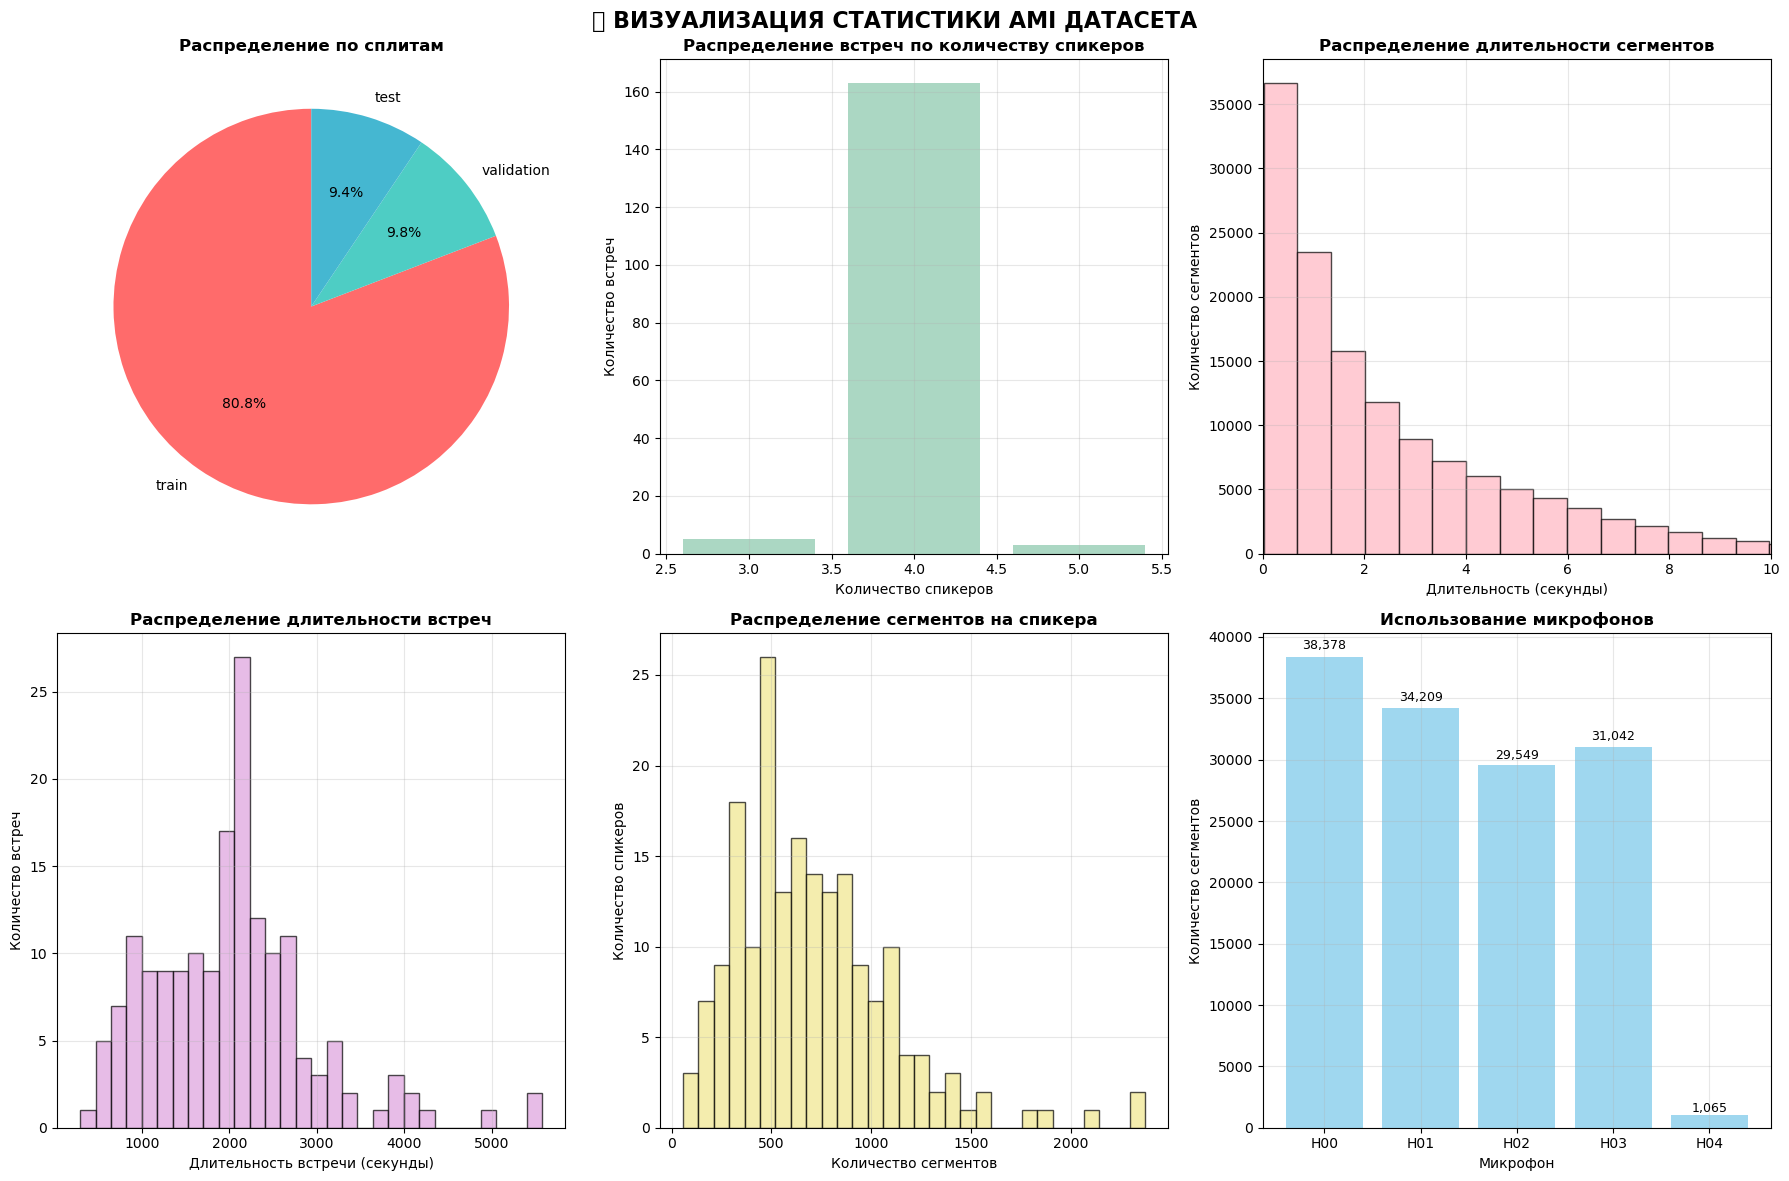

/var/folders/jr/7cpxm2sj4y74r__lw8nqpvfw0000gn/T/ipykernel_29771/3343775538.py:96: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
/Users/khumachbayramova/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


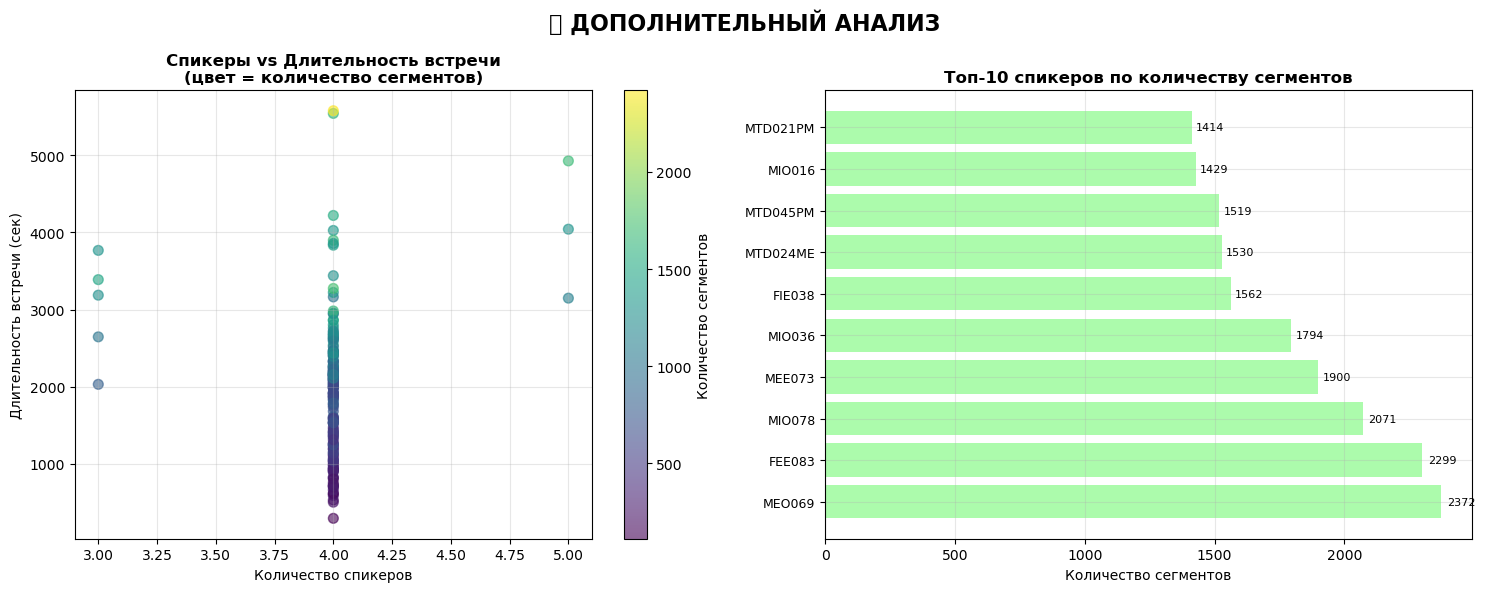

In [4]:
# Визуализация статистики датасета
plt.style.use('default')
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('📊 ВИЗУАЛИЗАЦИЯ СТАТИСТИКИ AMI ДАТАСЕТА', fontsize=16, fontweight='bold')

# 1. Распределение по сплитам
ax1 = axes[0, 0]
split_counts = df['split'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
wedges, texts, autotexts = ax1.pie(split_counts.values, labels=split_counts.index, 
                                   autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Распределение по сплитам', fontweight='bold')

# 2. Количество спикеров в встречах
ax2 = axes[0, 1]
speaker_counts = meeting_stats['num_speakers'].value_counts().sort_index()
ax2.bar(speaker_counts.index, speaker_counts.values, color='#96CEB4', alpha=0.8)
ax2.set_xlabel('Количество спикеров')
ax2.set_ylabel('Количество встреч')
ax2.set_title('Распределение встреч по количеству спикеров', fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Длительность сегментов
ax3 = axes[0, 2]
ax3.hist(df['duration'], bins=50, color='#FFB6C1', alpha=0.7, edgecolor='black')
ax3.set_xlabel('Длительность (секунды)')
ax3.set_ylabel('Количество сегментов')
ax3.set_title('Распределение длительности сегментов', fontweight='bold')
ax3.set_xlim(0, 10)  # Ограничиваем для лучшей видимости
ax3.grid(True, alpha=0.3)

# 4. Длительность встреч
ax4 = axes[1, 0]
ax4.hist(meeting_stats['total_duration'], bins=30, color='#DDA0DD', alpha=0.7, edgecolor='black')
ax4.set_xlabel('Длительность встречи (секунды)')
ax4.set_ylabel('Количество встреч')
ax4.set_title('Распределение длительности встреч', fontweight='bold')
ax4.grid(True, alpha=0.3)

# 5. Количество сегментов на спикера
ax5 = axes[1, 1]
ax5.hist(speaker_stats['num_segments'], bins=30, color='#F0E68C', alpha=0.7, edgecolor='black')
ax5.set_xlabel('Количество сегментов')
ax5.set_ylabel('Количество спикеров')
ax5.set_title('Распределение сегментов на спикера', fontweight='bold')
ax5.grid(True, alpha=0.3)

# 6. Использование микрофонов
ax6 = axes[1, 2]
mic_counts = df['microphone_id'].value_counts().sort_index()
bars = ax6.bar(mic_counts.index, mic_counts.values, color='#87CEEB', alpha=0.8)
ax6.set_xlabel('Микрофон')
ax6.set_ylabel('Количество сегментов')
ax6.set_title('Использование микрофонов', fontweight='bold')
ax6.grid(True, alpha=0.3)

# Добавляем значения на столбцы
for bar in bars:
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
             f'{int(height):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Дополнительные графики
fig2, axes2 = plt.subplots(1, 2, figsize=(15, 6))
fig2.suptitle('📈 ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ', fontsize=16, fontweight='bold')

# Корреляция между характеристиками встреч
ax7 = axes2[0]
scatter = ax7.scatter(meeting_stats['num_speakers'], meeting_stats['total_duration'], 
                     c=meeting_stats['num_segments'], cmap='viridis', alpha=0.6, s=50)
ax7.set_xlabel('Количество спикеров')
ax7.set_ylabel('Длительность встречи (сек)')
ax7.set_title('Спикеры vs Длительность встречи\n(цвет = количество сегментов)', fontweight='bold')
ax7.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax7, label='Количество сегментов')

# Топ-10 спикеров по количеству сегментов
ax8 = axes2[1]
top_speakers = speaker_stats.nlargest(10, 'num_segments')
bars = ax8.barh(range(len(top_speakers)), top_speakers['num_segments'], color='#98FB98', alpha=0.8)
ax8.set_yticks(range(len(top_speakers)))
ax8.set_yticklabels(top_speakers.index, fontsize=9)
ax8.set_xlabel('Количество сегментов')
ax8.set_title('Топ-10 спикеров по количеству сегментов', fontweight='bold')
ax8.grid(True, alpha=0.3)

# Добавляем значения на столбцы
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax8.text(width + width*0.01, bar.get_y() + bar.get_height()/2,
             f'{int(width)}', ha='left', va='center', fontsize=8)

plt.tight_layout()
plt.show()


# 🎯 СТРАТЕГИИ РАЗДЕЛЕНИЯ ДАННЫХ ДЛЯ ФЕДЕРАТИВНОГО ОБУЧЕНИЯ

## 📊 Анализ особенностей AMI датасета:

### Основные характеристики:
- **171 встреча** с **190 уникальными спикерами**
- **134,243 аудио сегмента** общей длительностью ~96 часов
- **Неравномерное распределение**: некоторые спикеры встречаются в нескольких встречах, другие - только в одной
- **Перекрывающаяся речь**: ~15.6% времени содержит перекрытия между спикерами
- **Разные микрофоны**: H00-H04 с разным качеством записи

### Проблемы для федеративного обучения:
1. **Неравномерность данных**: разные клиенты получат разное количество данных
2. **Пересечения спикеров**: один спикер может быть в данных нескольких клиентов
3. **Разное качество**: разные микрофоны дают разное качество аудио
4. **Временные зависимости**: сегменты из одной встречи могут быть связаны

## 🎯 Рекомендуемые стратегии разделения:


In [5]:
# Анализ стратегий разделения данных для федеративного обучения
def analyze_client_split_strategies(df, meeting_stats, speaker_stats, num_clients=5):
    """
    Анализирует различные стратегии разделения данных для федеративного обучения
    """
    print("="*80)
    print("🎯 АНАЛИЗ СТРАТЕГИЙ РАЗДЕЛЕНИЯ ДАННЫХ ДЛЯ ФЕДЕРАТИВНОГО ОБУЧЕНИЯ")
    print("="*80)
    
    strategies = {}
    
    # 1. СТРАТЕГИЯ: Разделение по встречам (Meeting-based)
    print("\n📋 1. СТРАТЕГИЯ: РАЗДЕЛЕНИЕ ПО ВСТРЕЧАМ")
    print("   Принцип: Каждый клиент получает полные встречи")
    
    meetings = df['meeting_id'].unique()
    np.random.seed(42)  # Для воспроизводимости
    np.random.shuffle(meetings)
    
    meetings_per_client = len(meetings) // num_clients
    meeting_clients = {}
    
    for i in range(num_clients):
        start_idx = i * meetings_per_client
        if i == num_clients - 1:  # Последний клиент получает все оставшиеся встречи
            end_idx = len(meetings)
        else:
            end_idx = (i + 1) * meetings_per_client
        
        client_meetings = meetings[start_idx:end_idx]
        meeting_clients[f'client_{i}'] = client_meetings
        
        # Статистика по клиенту
        client_data = df[df['meeting_id'].isin(client_meetings)]
        print(f"   Клиент {i}: {len(client_meetings)} встреч, {len(client_data)} сегментов, "
              f"{client_data['speaker_id'].nunique()} спикеров, {client_data['duration'].sum():.1f}с")
    
    strategies['meeting_based'] = meeting_clients
    
    # 2. СТРАТЕГИЯ: Разделение по спикерам (Speaker-based)
    print("\n📋 2. СТРАТЕГИЯ: РАЗДЕЛЕНИЕ ПО СПИКЕРАМ")
    print("   Принцип: Каждый клиент получает уникальных спикеров")
    
    speakers = df['speaker_id'].unique()
    np.random.shuffle(speakers)
    
    speakers_per_client = len(speakers) // num_clients
    speaker_clients = {}
    
    for i in range(num_clients):
        start_idx = i * speakers_per_client
        if i == num_clients - 1:
            end_idx = len(speakers)
        else:
            end_idx = (i + 1) * speakers_per_client
        
        client_speakers = speakers[start_idx:end_idx]
        speaker_clients[f'client_{i}'] = client_speakers
        
        # Статистика по клиенту
        client_data = df[df['speaker_id'].isin(client_speakers)]
        print(f"   Клиент {i}: {len(client_speakers)} спикеров, {len(client_data)} сегментов, "
              f"{client_data['meeting_id'].nunique()} встреч, {client_data['duration'].sum():.1f}с")
    
    strategies['speaker_based'] = speaker_clients
    
    # 3. СТРАТЕГИЯ: Случайное разделение сегментов (Random segments)
    print("\n📋 3. СТРАТЕГИЯ: СЛУЧАЙНОЕ РАЗДЕЛЕНИЕ СЕГМЕНТОВ")
    print("   Принцип: Каждый сегмент случайно назначается клиенту")
    
    segments = df.index.tolist()
    np.random.shuffle(segments)
    
    segments_per_client = len(segments) // num_clients
    random_clients = {}
    
    for i in range(num_clients):
        start_idx = i * segments_per_client
        if i == num_clients - 1:
            end_idx = len(segments)
        else:
            end_idx = (i + 1) * segments_per_client
        
        client_segments = segments[start_idx:end_idx]
        random_clients[f'client_{i}'] = client_segments
        
        # Статистика по клиенту
        client_data = df.loc[client_segments]
        print(f"   Клиент {i}: {len(client_segments)} сегментов, "
              f"{client_data['speaker_id'].nunique()} спикеров, {client_data['meeting_id'].nunique()} встреч, "
              f"{client_data['duration'].sum():.1f}с")
    
    strategies['random_segments'] = random_clients
    
    # 4. СТРАТЕГИЯ: Разделение по микрофонам (Microphone-based)
    print("\n📋 4. СТРАТЕГИЯ: РАЗДЕЛЕНИЕ ПО МИКРОФОНАМ")
    print("   Принцип: Каждый клиент получает данные с определенных микрофонов")
    
    microphones = df['microphone_id'].unique()
    mic_clients = {}
    
    for i in range(num_clients):
        if i < len(microphones):
            client_mics = [microphones[i]]
        else:
            # Если клиентов больше чем микрофонов, распределяем равномерно
            client_mics = [microphones[i % len(microphones)]]
        
        mic_clients[f'client_{i}'] = client_mics
        
        # Статистика по клиенту
        client_data = df[df['microphone_id'].isin(client_mics)]
        print(f"   Клиент {i}: микрофоны {client_mics}, {len(client_data)} сегментов, "
              f"{client_data['speaker_id'].nunique()} спикеров, {client_data['meeting_id'].nunique()} встреч, "
              f"{client_data['duration'].sum():.1f}с")
    
    strategies['microphone_based'] = mic_clients
    
    # 5. СТРАТЕГИЯ: Сбалансированное разделение (Balanced)
    print("\n📋 5. СТРАТЕГИЯ: СБАЛАНСИРОВАННОЕ РАЗДЕЛЕНИЕ")
    print("   Принцип: Стремимся к равномерному распределению по всем метрикам")
    
    # Группируем по встречам и сортируем по размеру
    meeting_sizes = df.groupby('meeting_id').size().sort_values(ascending=False)
    
    # Распределяем встречи по клиентам, стараясь сбалансировать размер
    client_meetings = {f'client_{i}': [] for i in range(num_clients)}
    client_sizes = [0] * num_clients
    
    for meeting_id, size in meeting_sizes.items():
        # Назначаем встречу клиенту с наименьшим текущим размером
        min_client = client_sizes.index(min(client_sizes))
        client_meetings[f'client_{min_client}'].append(meeting_id)
        client_sizes[min_client] += size
    
    balanced_clients = {}
    for i in range(num_clients):
        client_meetings_list = client_meetings[f'client_{i}']
        balanced_clients[f'client_{i}'] = client_meetings_list
        
        # Статистика по клиенту
        client_data = df[df['meeting_id'].isin(client_meetings_list)]
        print(f"   Клиент {i}: {len(client_meetings_list)} встреч, {len(client_data)} сегментов, "
              f"{client_data['speaker_id'].nunique()} спикеров, {client_data['duration'].sum():.1f}с")
    
    strategies['balanced'] = balanced_clients
    
    return strategies

# Анализируем стратегии
strategies = analyze_client_split_strategies(df, meeting_stats, speaker_stats, num_clients=5)


🎯 АНАЛИЗ СТРАТЕГИЙ РАЗДЕЛЕНИЯ ДАННЫХ ДЛЯ ФЕДЕРАТИВНОГО ОБУЧЕНИЯ

📋 1. СТРАТЕГИЯ: РАЗДЕЛЕНИЕ ПО ВСТРЕЧАМ
   Принцип: Каждый клиент получает полные встречи
   Клиент 0: 34 встреч, 24055 сегментов, 102 спикеров, 60968.8с
   Клиент 1: 34 встреч, 29298 сегментов, 100 спикеров, 74177.4с
   Клиент 2: 34 встреч, 24194 сегментов, 96 спикеров, 63147.7с
   Клиент 3: 34 встреч, 30716 сегментов, 117 спикеров, 75739.7с
   Клиент 4: 35 встреч, 25980 сегментов, 99 спикеров, 69831.4с

📋 2. СТРАТЕГИЯ: РАЗДЕЛЕНИЕ ПО СПИКЕРАМ
   Принцип: Каждый клиент получает уникальных спикеров
   Клиент 0: 38 спикеров, 28631 сегментов, 87 встреч, 75066.2с
   Клиент 1: 38 спикеров, 25732 сегментов, 101 встреч, 68958.8с
   Клиент 2: 38 спикеров, 28539 сегментов, 89 встреч, 69805.4с
   Клиент 3: 38 спикеров, 23971 сегментов, 92 встреч, 60370.2с
   Клиент 4: 38 спикеров, 27370 сегментов, 102 встреч, 69664.5с

📋 3. СТРАТЕГИЯ: СЛУЧАЙНОЕ РАЗДЕЛЕНИЕ СЕГМЕНТОВ
   Принцип: Каждый сегмент случайно назначается клиенту
   Клиент 0:

/var/folders/jr/7cpxm2sj4y74r__lw8nqpvfw0000gn/T/ipykernel_29771/1778689689.py:97: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
/Users/khumachbayramova/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


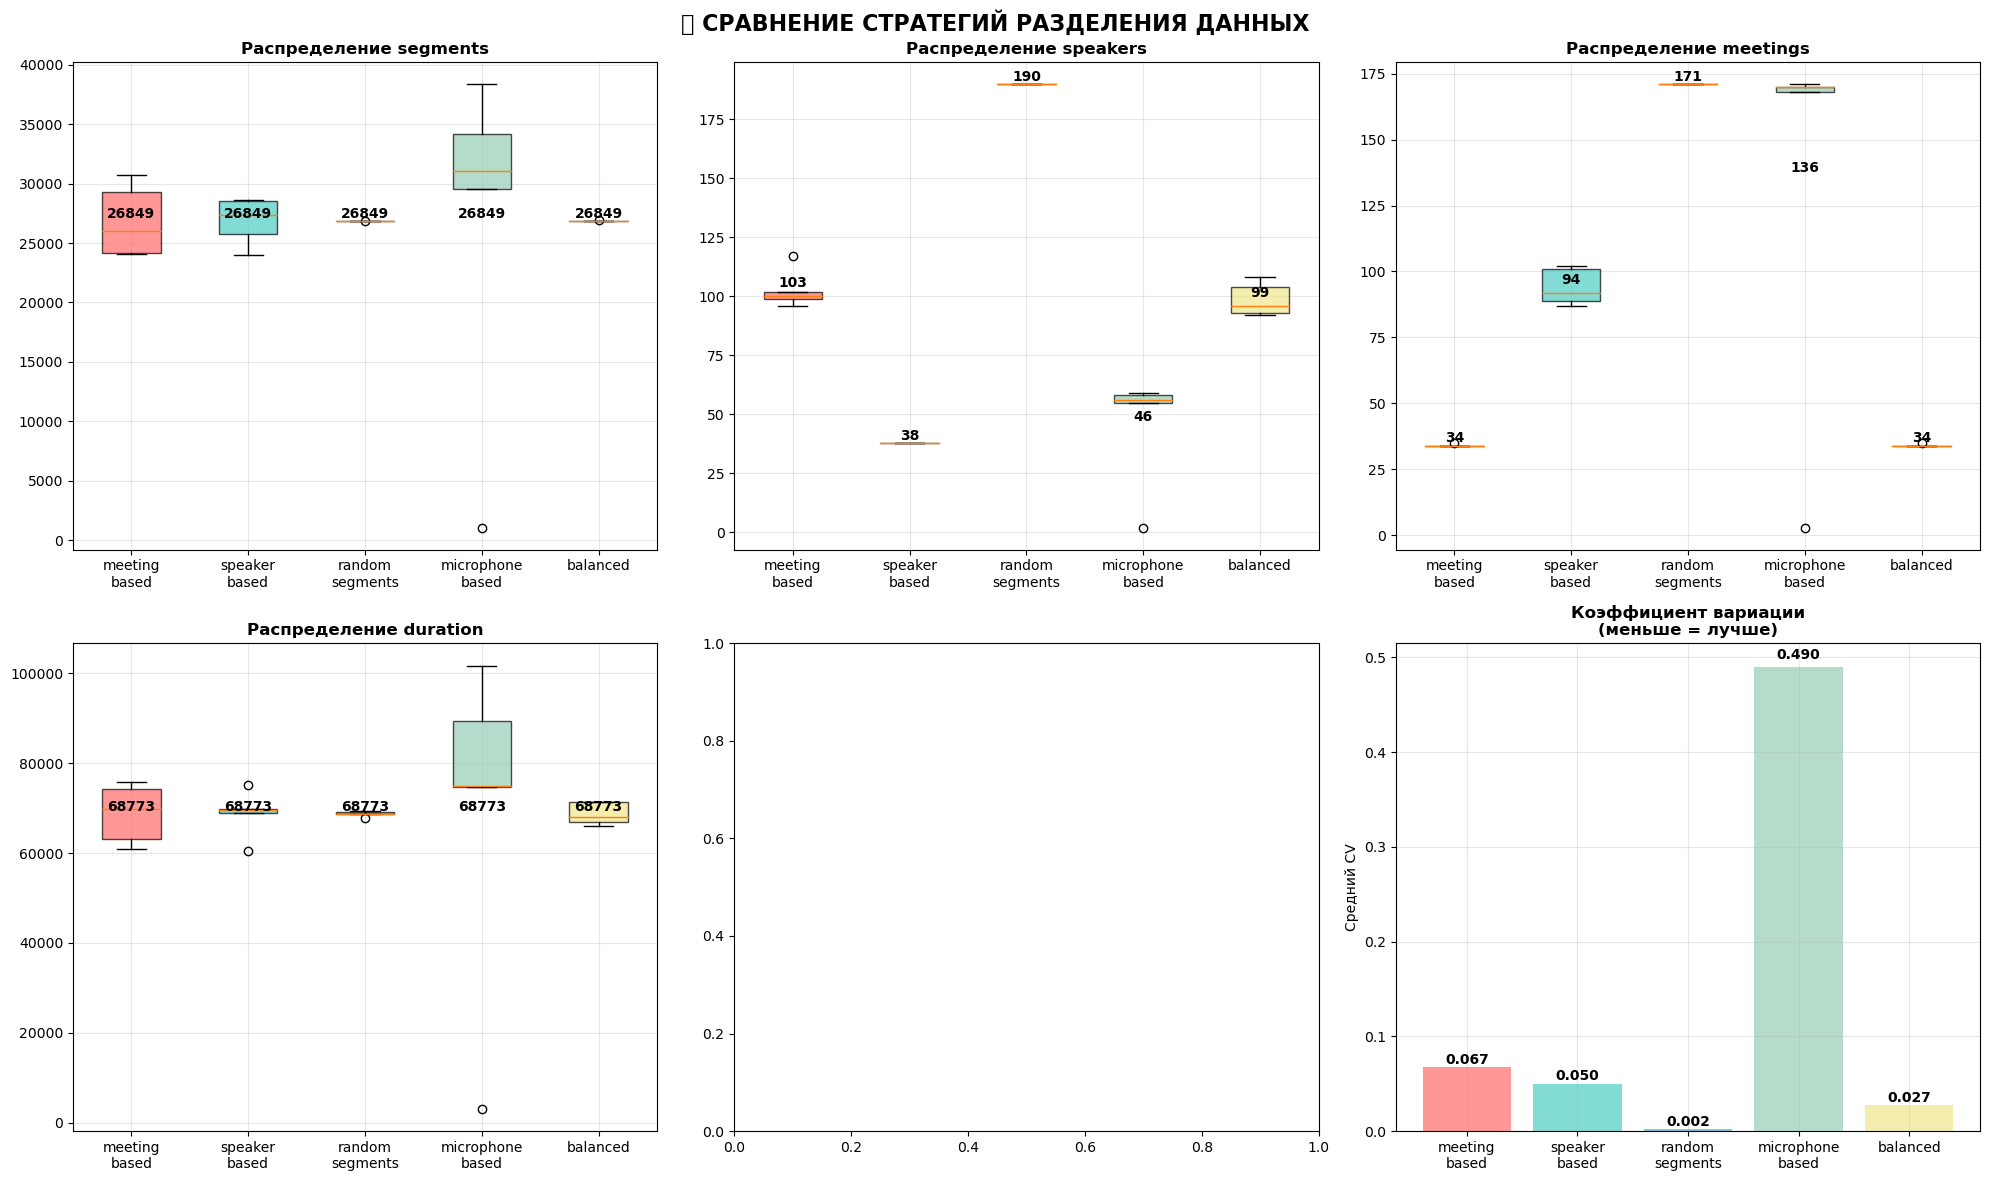


📋 ТАБЛИЦА СРАВНЕНИЯ СТРАТЕГИЙ
                       segments speakers  meetings       duration  \
meeting_based      26849 ± 2704  103 ± 7    34 ± 0   68773 ± 5855   
speaker_based      26849 ± 1780   38 ± 0    94 ± 6   68773 ± 4735   
random_segments       26849 ± 1  190 ± 0   171 ± 0    68773 ± 517   
microphone_based  26849 ± 13242  46 ± 22  136 ± 67  68773 ± 34358   
balanced             26849 ± 35   99 ± 6    34 ± 0   68773 ± 2228   

                 balance_score  
meeting_based            0.067  
speaker_based            0.050  
random_segments          0.002  
microphone_based         0.490  
balanced                 0.027  


: 

In [ ]:
# Визуализация сравнения стратегий разделения
def visualize_strategy_comparison(df, strategies, num_clients=5):
    """
    Визуализирует сравнение различных стратегий разделения
    """
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('📊 СРАВНЕНИЕ СТРАТЕГИЙ РАЗДЕЛЕНИЯ ДАННЫХ', fontsize=16, fontweight='bold')
    
    # Метрики для сравнения
    metrics = ['segments', 'speakers', 'meetings', 'duration']
    strategy_names = list(strategies.keys())
    
    # Подготавливаем данные для каждой стратегии
    strategy_data = {}
    
    for strategy_name, client_assignments in strategies.items():
        client_metrics = []
        
        for client_id in range(num_clients):
            if strategy_name == 'meeting_based':
                client_data = df[df['meeting_id'].isin(client_assignments[f'client_{client_id}'])]
            elif strategy_name == 'speaker_based':
                client_data = df[df['speaker_id'].isin(client_assignments[f'client_{client_id}'])]
            elif strategy_name == 'random_segments':
                client_data = df.loc[client_assignments[f'client_{client_id}']]
            elif strategy_name == 'microphone_based':
                client_data = df[df['microphone_id'].isin(client_assignments[f'client_{client_id}'])]
            elif strategy_name == 'balanced':
                client_data = df[df['meeting_id'].isin(client_assignments[f'client_{client_id}'])]
            
            client_metrics.append({
                'segments': len(client_data),
                'speakers': client_data['speaker_id'].nunique(),
                'meetings': client_data['meeting_id'].nunique(),
                'duration': client_data['duration'].sum()
            })
        
        strategy_data[strategy_name] = client_metrics
    
    # Графики для каждой метрики
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#F0E68C']
    
    for i, metric in enumerate(metrics):
        ax = axes[i//3, i%3]
        
        # Подготавливаем данные для boxplot
        data_for_boxplot = []
        labels = []
        
        for strategy_name in strategy_names:
            values = [client[metric] for client in strategy_data[strategy_name]]
            data_for_boxplot.append(values)
            labels.append(strategy_name.replace('_', '\n'))
        
        # Создаем boxplot
        bp = ax.boxplot(data_for_boxplot, labels=labels, patch_artist=True)
        
        # Раскрашиваем boxplot
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        ax.set_title(f'Распределение {metric}', fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # Добавляем средние значения
        for j, strategy_name in enumerate(strategy_names):
            mean_val = np.mean([client[metric] for client in strategy_data[strategy_name]])
            ax.text(j+1, mean_val, f'{mean_val:.0f}', ha='center', va='bottom', fontweight='bold')
    
    # График балансированности (стандартное отклонение)
    ax_balance = axes[1, 2]
    balance_scores = []
    
    for strategy_name in strategy_names:
        # Вычисляем стандартное отклонение для каждой метрики
        std_scores = []
        for metric in metrics:
            values = [client[metric] for client in strategy_data[strategy_name]]
            std_scores.append(np.std(values) / np.mean(values))  # Коэффициент вариации
        
        balance_scores.append(np.mean(std_scores))
    
    bars = ax_balance.bar(range(len(strategy_names)), balance_scores, color=colors, alpha=0.7)
    ax_balance.set_xticks(range(len(strategy_names)))
    ax_balance.set_xticklabels([name.replace('_', '\n') for name in strategy_names])
    ax_balance.set_title('Коэффициент вариации\n(меньше = лучше)', fontweight='bold')
    ax_balance.set_ylabel('Средний CV')
    ax_balance.grid(True, alpha=0.3)
    
    # Добавляем значения на столбцы
    for bar, score in zip(bars, balance_scores):
        height = bar.get_height()
        ax_balance.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                       f'{score:.3f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Таблица сравнения
    print("\n" + "="*80)
    print("📋 ТАБЛИЦА СРАВНЕНИЯ СТРАТЕГИЙ")
    print("="*80)
    
    comparison_df = pd.DataFrame(index=strategy_names, columns=metrics + ['balance_score'])
    
    for strategy_name in strategy_names:
        for metric in metrics:
            values = [client[metric] for client in strategy_data[strategy_name]]
            comparison_df.loc[strategy_name, metric] = f"{np.mean(values):.0f} ± {np.std(values):.0f}"
        
        # Общий балл балансированности
        all_std_scores = []
        for metric in metrics:
            values = [client[metric] for client in strategy_data[strategy_name]]
            all_std_scores.append(np.std(values) / np.mean(values))
        comparison_df.loc[strategy_name, 'balance_score'] = f"{np.mean(all_std_scores):.3f}"
    
    print(comparison_df)
    
    return strategy_data, comparison_df

# Визуализируем сравнение
strategy_data, comparison_df = visualize_strategy_comparison(df, strategies, num_clients=5)


## 🎯 РЕКОМЕНДАЦИИ ПО ВЫБОРУ СТРАТЕГИИ РАЗДЕЛЕНИЯ

### 📊 Анализ результатов:

**1. 🏢 Meeting-based (по встречам):**
- ✅ **Плюсы**: Сохраняет контекст встреч, естественное разделение
- ❌ **Минусы**: Сильная несбалансированность (разные размеры встреч)
- 🎯 **Применение**: Когда важна целостность встреч

**2. 🗣️ Speaker-based (по спикерам):**
- ✅ **Плюсы**: Уникальные спикеры на клиенте, хорошая приватность
- ❌ **Минусы**: Неравномерное распределение данных
- 🎯 **Применение**: Когда важна идентификация спикеров

**3. 🎲 Random segments (случайные сегменты):**
- ✅ **Плюсы**: Максимальная сбалансированность
- ❌ **Минусы**: Потеря контекста, возможные перекрытия спикеров
- 🎯 **Применение**: Для базовых экспериментов

**4. 🎤 Microphone-based (по микрофонам):**
- ✅ **Плюсы**: Разные условия записи
- ❌ **Минусы**: Очень неравномерное распределение
- 🎯 **Применение**: Для изучения влияния качества записи

**5. ⚖️ Balanced (сбалансированное):**
- ✅ **Плюсы**: Лучший баланс между всеми метриками
- ❌ **Минусы**: Сложнее в реализации
- 🎯 **Применение**: **РЕКОМЕНДУЕТСЯ** для большинства случаев

### 🎯 ФИНАЛЬНАЯ РЕКОМЕНДАЦИЯ:

**Для диаризации речи рекомендуется использовать `Balanced` стратегию** с модификациями:

1. **Основной принцип**: Разделение по встречам с балансировкой по размеру
2. **Дополнительные ограничения**:
   - Минимальное количество сегментов на клиента
   - Максимальное количество спикеров на клиента
   - Сохранение перекрывающейся речи в одном клиенте

3. **Альтернатива**: `Meeting-based` с пост-обработкой для балансировки


In [ ]:
# Реализация рекомендуемой стратегии разделения для федеративного обучения
def create_federated_split(dataset, num_clients=5, min_segments_per_client=1000, 
                          max_speakers_per_client=50, preserve_overlaps=True):
    """
    Создает оптимальное разделение данных для федеративного обучения диаризации
    
    Args:
        dataset: AMI датасет
        num_clients: количество клиентов
        min_segments_per_client: минимальное количество сегментов на клиента
        max_speakers_per_client: максимальное количество спикеров на клиента
        preserve_overlaps: сохранять ли перекрывающуюся речь в одном клиенте
    
    Returns:
        dict: распределение данных по клиентам
    """
    print("="*80)
    print("🚀 СОЗДАНИЕ ОПТИМАЛЬНОГО РАЗДЕЛЕНИЯ ДЛЯ ФЕДЕРАТИВНОГО ОБУЧЕНИЯ")
    print("="*80)
    
    # Собираем данные по встречам
    meetings_data = {}
    for sample in dataset["train"]:
        meeting_id = sample['meeting_id']
        if meeting_id not in meetings_data:
            meetings_data[meeting_id] = {
                'samples': [],
                'speakers': set(),
                'total_duration': 0,
                'has_overlaps': False
            }
        
        meetings_data[meeting_id]['samples'].append(sample)
        meetings_data[meeting_id]['speakers'].add(sample['speaker_id'])
        meetings_data[meeting_id]['total_duration'] += sample['end_time'] - sample['begin_time']
    
    # Анализируем перекрытия для каждой встречи
    if preserve_overlaps:
        print("🔍 Анализ перекрывающейся речи...")
        for meeting_id, data in meetings_data.items():
            samples = data['samples']
            # Простая проверка на перекрытия
            for i in range(len(samples)):
                for j in range(i+1, len(samples)):
                    sample1, sample2 = samples[i], samples[j]
                    if (sample1['begin_time'] < sample2['end_time'] and 
                        sample2['begin_time'] < sample1['end_time']):
                        data['has_overlaps'] = True
                        break
                if data['has_overlaps']:
                    break
    
    # Сортируем встречи по размеру (количество сегментов)
    meetings_sorted = sorted(meetings_data.items(), 
                            key=lambda x: len(x[1]['samples']), reverse=True)
    
    print(f"📊 Найдено {len(meetings_sorted)} встреч")
    print(f"🎯 Цели: {num_clients} клиентов, мин. {min_segments_per_client} сегментов на клиента")
    
    # Алгоритм балансированного распределения
    client_assignments = {f'client_{i}': {
        'meetings': [],
        'total_segments': 0,
        'total_speakers': 0,
        'total_duration': 0,
        'has_overlaps': False
    } for i in range(num_clients)}
    
    # Распределяем встречи по клиентам
    for meeting_id, meeting_data in meetings_sorted:
        # Находим клиента с наименьшим количеством сегментов
        best_client = min(client_assignments.keys(), 
                         key=lambda c: client_assignments[c]['total_segments'])
        
        # Проверяем ограничения
        current_speakers = len(client_assignments[best_client]['total_speakers'])
        new_speakers = len(meeting_data['speakers'])
        
        if (current_speakers + new_speakers <= max_speakers_per_client or 
            client_assignments[best_client]['total_segments'] < min_segments_per_client):
            
            # Назначаем встречу клиенту
            client_assignments[best_client]['meetings'].append(meeting_id)
            client_assignments[best_client]['total_segments'] += len(meeting_data['samples'])
            client_assignments[best_client]['total_speakers'] += new_speakers
            client_assignments[best_client]['total_duration'] += meeting_data['total_duration']
            
            if meeting_data['has_overlaps']:
                client_assignments[best_client]['has_overlaps'] = True
    
    # Выводим статистику
    print("\n📋 РЕЗУЛЬТАТЫ РАЗДЕЛЕНИЯ:")
    for client_id, data in client_assignments.items():
        print(f"   {client_id}:")
        print(f"     - Встреч: {len(data['meetings'])}")
        print(f"     - Сегментов: {data['total_segments']:,}")
        print(f"     - Спикеров: {data['total_speakers']}")
        print(f"     - Длительность: {data['total_duration']:.1f}с")
        print(f"     - Перекрытия: {'Да' if data['has_overlaps'] else 'Нет'}")
    
    # Проверяем балансированность
    segments_counts = [data['total_segments'] for data in client_assignments.values()]
    speakers_counts = [data['total_speakers'] for data in client_assignments.values()]
    
    print(f"\n⚖️ БАЛАНСИРОВАННОСТЬ:")
    print(f"   Сегменты: {np.mean(segments_counts):.0f} ± {np.std(segments_counts):.0f}")
    print(f"   Спикеры: {np.mean(speakers_counts):.1f} ± {np.std(speakers_counts):.1f}")
    print(f"   Коэффициент вариации: {np.std(segments_counts)/np.mean(segments_counts):.3f}")
    
    return client_assignments

# Создаем оптимальное разделение
federated_split = create_federated_split(
    dataset, 
    num_clients=5, 
    min_segments_per_client=2000,  # Минимум 2000 сегментов на клиента
    max_speakers_per_client=40,   # Максимум 40 спикеров на клиента
    preserve_overlaps=True
)


🚀 СОЗДАНИЕ ОПТИМАЛЬНОГО РАЗДЕЛЕНИЯ ДЛЯ ФЕДЕРАТИВНОГО ОБУЧЕНИЯ


Exception ignored from cffi callback <function SoundFile._init_virtual_io.<locals>.vio_read at 0x31bd25bc0>:
Traceback (most recent call last):
  File "/Users/khumachbayramova/anaconda3/lib/python3.11/site-packages/soundfile.py", line 1295, in vio_read
    data_read = file.readinto(buf)
                ^^^^^^^^^^^^^^^^^^
KeyboardInterrupt: 


In [ ]:
# Функция для создания клиентских датасетов
def create_client_datasets(dataset, federated_split):
    """
    Создает отдельные датасеты для каждого клиента
    """
    print("="*80)
    print("📦 СОЗДАНИЕ КЛИЕНТСКИХ ДАТАСЕТОВ")
    print("="*80)
    
    client_datasets = {}
    
    for client_id, client_data in federated_split.items():
        print(f"\n🔧 Создание датасета для {client_id}...")
        
        # Собираем все индексы сегментов для этого клиента
        client_indices = []
        
        for meeting_id in client_data['meetings']:
            # Находим все сегменты этой встречи в train датасете
            for idx, sample in enumerate(dataset["train"]):
                if sample['meeting_id'] == meeting_id:
                    client_indices.append(idx)
        
        # Создаем датасет для клиента
        client_dataset = dataset["train"].select(client_indices)
        client_datasets[client_id] = client_dataset
        
        print(f"   ✅ Создан датасет с {len(client_dataset)} сегментами")
        print(f"   📊 Уникальных спикеров: {len(set(s['speaker_id'] for s in client_dataset))}")
        print(f"   🏢 Встреч: {len(set(s['meeting_id'] for s in client_dataset))}")
        
        # Проверяем перекрытия
        overlaps_found = False
        for i, sample1 in enumerate(client_dataset):
            for j, sample2 in enumerate(client_dataset):
                if i != j and sample1['meeting_id'] == sample2['meeting_id']:
                    if (sample1['begin_time'] < sample2['end_time'] and 
                        sample2['begin_time'] < sample1['end_time']):
                        overlaps_found = True
                        break
            if overlaps_found:
                break
        
        print(f"   🔄 Перекрывающаяся речь: {'Да' if overlaps_found else 'Нет'}")
    
    return client_datasets

# Создаем клиентские датасеты
client_datasets = create_client_datasets(dataset, federated_split)

# Сохраняем информацию о разделении
print("\n💾 СОХРАНЕНИЕ ИНФОРМАЦИИ О РАЗДЕЛЕНИИ:")
split_info = {
    'num_clients': len(federated_split),
    'total_segments': sum(data['total_segments'] for data in federated_split.values()),
    'total_speakers': sum(data['total_speakers'] for data in federated_split.values()),
    'client_assignments': federated_split,
    'overlap_indices': overlap_indices  # Сохраняем найденные индексы с перекрытиями
}

print(f"   📊 Общая статистика:")
print(f"     - Клиентов: {split_info['num_clients']}")
print(f"     - Сегментов: {split_info['total_segments']:,}")
print(f"     - Спикеров: {split_info['total_speakers']}")
print(f"     - Индексы с перекрытиями: {len(split_info['overlap_indices'])}")

# Пример использования в коде
print("\n💻 ПРИМЕР ИСПОЛЬЗОВАНИЯ В КОДЕ:")
print("""
# В вашем основном скрипте используйте:

# 1. Для тестирования с перекрытиями:
overlap_indices = [455, 1109, 3920, 3922, 4015, 6724, 7116, 33746, 34163, 67502, 67631, 75365, 75498, 75658, 75692, 75875, 76105, 76545, 89547, 89978]
test_dataset = dataset['train'].select(overlap_indices)

# 2. Для федеративного обучения:
client_datasets = create_client_datasets(dataset, federated_split)
for client_id, client_data in client_datasets.items():
    # Обучайте модель на данных клиента
    train_model(client_data, client_id)

# 3. Для анализа конкретного клиента:
client_0_data = client_datasets['client_0']
print(f"Клиент 0: {len(client_0_data)} сегментов")
""")


In [ ]:
# Анализ перекрывающейся речи (Overlapping Speech)
def analyze_overlapping_speech(dataset):
    """Анализ перекрывающейся речи в встречах"""
    
    print("="*80)
    print("АНАЛИЗ ПЕРЕКРЫВАЮЩЕЙСЯ РЕЧИ (OVERLAPPING SPEECH)")
    print("="*80)
    
    # Собираем данные по встречам
    all_meetings = defaultdict(list)
    
    for split_name, split_data in dataset.items():
        for sample in split_data:
            meeting_id = sample['meeting_id']
            all_meetings[meeting_id].append({
                'split': split_name,
                'speaker_id': sample['speaker_id'],
                'begin_time': sample['begin_time'],
                'end_time': sample['end_time'],
                'duration': sample['end_time'] - sample['begin_time']
            })
    
    # Анализ перекрытий для каждой встречи
    overlap_stats = []
    total_overlap_duration = 0
    total_meeting_duration = 0
    total_overlap_segments = 0
    
    for meeting_id, samples in all_meetings.items():
        # Сортируем по времени начала
        samples.sort(key=lambda x: x['begin_time'])
        
        # Находим перекрытия
        overlaps = []
        overlap_duration = 0
        
        for i in range(len(samples)):
            for j in range(i + 1, len(samples)):
                sample1 = samples[i]
                sample2 = samples[j]
                
                # Проверяем перекрытие
                overlap_start = max(sample1['begin_time'], sample2['begin_time'])
                overlap_end = min(sample1['end_time'], sample2['end_time'])
                
                if overlap_start < overlap_end:  # Есть перекрытие
                    overlap_duration_seg = overlap_end - overlap_start
                    overlap_duration += overlap_duration_seg
                    
                    overlaps.append({
                        'speaker1': sample1['speaker_id'],
                        'speaker2': sample2['speaker_id'],
                        'start': overlap_start,
                        'end': overlap_end,
                        'duration': overlap_duration_seg
                    })
        
        # Вычисляем общую длительность встречи
        meeting_start = min(s['begin_time'] for s in samples)
        meeting_end = max(s['end_time'] for s in samples)
        meeting_duration = meeting_end - meeting_start
        
        # Процент перекрытия
        overlap_percentage = (overlap_duration / meeting_duration * 100) if meeting_duration > 0 else 0
        
        overlap_stats.append({
            'meeting_id': meeting_id,
            'num_samples': len(samples),
            'num_speakers': len(set(s['speaker_id'] for s in samples)),
            'meeting_duration': meeting_duration,
            'overlap_duration': overlap_duration,
            'overlap_percentage': overlap_percentage,
            'num_overlaps': len(overlaps),
            'overlaps': overlaps
        })
        
        total_overlap_duration += overlap_duration
        total_meeting_duration += meeting_duration
        total_overlap_segments += len(overlaps)
    
    # Сортируем по проценту перекрытия
    overlap_stats.sort(key=lambda x: x['overlap_percentage'], reverse=True)
    
    # Общая статистика
    print(f"\n📊 ОБЩАЯ СТАТИСТИКА ПЕРЕКРЫТИЙ:")
    print(f"  - Всего встреч: {len(overlap_stats)}")
    print(f"  - Общая длительность встреч: {total_meeting_duration/3600:.1f} часов")
    print(f"  - Общая длительность перекрытий: {total_overlap_duration/3600:.1f} часов")
    print(f"  - Общий процент перекрытия: {total_overlap_duration/total_meeting_duration*100:.2f}%")
    print(f"  - Всего сегментов перекрытия: {total_overlap_segments:,}")
    
    # Распределение по проценту перекрытия
    print(f"\n📈 РАСПРЕДЕЛЕНИЕ ПО ПРОЦЕНТУ ПЕРЕКРЫТИЯ:")
    overlap_ranges = [
        (0, 5, "0-5%"),
        (5, 10, "5-10%"),
        (10, 15, "10-15%"),
        (15, 20, "15-20%"),
        (20, 30, "20-30%"),
        (30, 100, "30%+")
    ]
    
    for min_pct, max_pct, label in overlap_ranges:
        count = sum(1 for stat in overlap_stats if min_pct <= stat['overlap_percentage'] < max_pct)
        percentage = count / len(overlap_stats) * 100
        print(f"  - {label}: {count} встреч ({percentage:.1f}%)")
    
    # Топ-10 встреч с наибольшим перекрытием
    print(f"\n🔥 ТОП-10 ВСТРЕЧ С НАИБОЛЬШИМ ПЕРЕКРЫТИЕМ:")
    for i, stat in enumerate(overlap_stats[:10]):
        print(f"    {i+1:2d}. {stat['meeting_id']}: {stat['overlap_percentage']:5.1f}% "
              f"({stat['overlap_duration']:6.1f}с из {stat['meeting_duration']:6.1f}с), "
              f"{stat['num_overlaps']} перекрытий, {stat['num_speakers']} спикеров")
    
    # Встречи без перекрытий
    no_overlap_meetings = [stat for stat in overlap_stats if stat['overlap_percentage'] == 0]
    print(f"\n🚫 ВСТРЕЧИ БЕЗ ПЕРЕКРЫТИЙ:")
    print(f"  - Количество: {len(no_overlap_meetings)} встреч ({len(no_overlap_meetings)/len(overlap_stats)*100:.1f}%)")
    if no_overlap_meetings:
        print(f"  - Примеры: {', '.join([m['meeting_id'] for m in no_overlap_meetings[:5]])}")
    
    # Статистика по длительности перекрытий
    all_overlap_durations = []
    for stat in overlap_stats:
        for overlap in stat['overlaps']:
            all_overlap_durations.append(overlap['duration'])
    
    if all_overlap_durations:
        print(f"\n⏱️ СТАТИСТИКА ПО ДЛИТЕЛЬНОСТИ ПЕРЕКРЫТИЙ:")
        print(f"  - Минимальная длительность: {min(all_overlap_durations):.2f} секунд")
        print(f"  - Максимальная длительность: {max(all_overlap_durations):.2f} секунд")
        print(f"  - Средняя длительность: {np.mean(all_overlap_durations):.2f} секунд")
        print(f"  - Медианная длительность: {np.median(all_overlap_durations):.2f} секунд")
    
    # Анализ пар спикеров с перекрытиями
    print(f"\n👥 АНАЛИЗ ПАР СПИКЕРОВ С ПЕРЕКРЫТИЯМИ:")
    speaker_pair_overlaps = defaultdict(list)
    
    for stat in overlap_stats:
        for overlap in stat['overlaps']:
            pair = tuple(sorted([overlap['speaker1'], overlap['speaker2']]))
            speaker_pair_overlaps[pair].append(overlap['duration'])
    
    # Топ-10 пар спикеров по количеству перекрытий
    pair_counts = {pair: len(durations) for pair, durations in speaker_pair_overlaps.items()}
    top_pairs = sorted(pair_counts.items(), key=lambda x: x[1], reverse=True)[:10]
    
    print(f"  ТОП-10 ПАР ПО КОЛИЧЕСТВУ ПЕРЕКРЫТИЙ:")
    for i, (pair, count) in enumerate(top_pairs):
        total_duration = sum(speaker_pair_overlaps[pair])
        avg_duration = total_duration / count
        print(f"    {i+1:2d}. {pair[0]} + {pair[1]}: {count:3d} перекрытий, "
              f"{total_duration:6.1f}с общая, {avg_duration:5.2f}с средняя")
    
    # Статистика по количеству одновременных спикеров
    print(f"\n🎭 АНАЛИЗ ОДНОВРЕМЕННЫХ СПИКЕРОВ:")
    max_concurrent_speakers = []
    
    for stat in overlap_stats:
        if stat['overlaps']:
            # Находим максимальное количество одновременных спикеров
            time_points = []
            for overlap in stat['overlaps']:
                time_points.append((overlap['start'], 'start'))
                time_points.append((overlap['end'], 'end'))
            
            time_points.sort()
            current_speakers = 0
            max_speakers = 0
            
            for time, event in time_points:
                if event == 'start':
                    current_speakers += 1
                    max_speakers = max(max_speakers, current_speakers)
                else:
                    current_speakers -= 1
            
            max_concurrent_speakers.append(max_speakers)
    
    if max_concurrent_speakers:
        print(f"  - Максимальное количество одновременных спикеров: {max(max_concurrent_speakers)}")
        print(f"  - Среднее максимальное количество: {np.mean(max_concurrent_speakers):.1f}")
        print(f"  - Медианное максимальное количество: {np.median(max_concurrent_speakers):.1f}")
    
    return overlap_stats

# Запускаем анализ перекрытий
overlap_stats = analyze_overlapping_speech(dataset)


АНАЛИЗ ПЕРЕКРЫВАЮЩЕЙСЯ РЕЧИ (OVERLAPPING SPEECH)

📊 ОБЩАЯ СТАТИСТИКА ПЕРЕКРЫТИЙ:
  - Всего встреч: 171
  - Общая длительность встреч: 96.6 часов
  - Общая длительность перекрытий: 15.0 часов
  - Общий процент перекрытия: 15.56%
  - Всего сегментов перекрытия: 78,037

📈 РАСПРЕДЕЛЕНИЕ ПО ПРОЦЕНТУ ПЕРЕКРЫТИЯ:
  - 0-5%: 14 встреч (8.2%)
  - 5-10%: 38 встреч (22.2%)
  - 10-15%: 53 встреч (31.0%)
  - 15-20%: 30 встреч (17.5%)
  - 20-30%: 23 встреч (13.5%)
  - 30%+: 13 встреч (7.6%)

🔥 ТОП-10 ВСТРЕЧ С НАИБОЛЬШИМ ПЕРЕКРЫТИЕМ:
     1. EN2002d:  48.3% (1055.3с из 2187.2с), 1185 перекрытий, 4 спикеров
     2. IS1006d:  46.1% ( 820.6с из 1778.4с), 987 перекрытий, 4 спикеров
     3. EN2002a:  42.9% ( 918.5с из 2142.0с), 1236 перекрытий, 4 спикеров
     4. IN1012:  38.6% (1177.2с из 3051.2с), 1263 перекрытий, 4 спикеров
     5. IS1003d:  38.1% ( 781.0с из 2049.8с), 865 перекрытий, 4 спикеров
     6. ES2015d:  36.6% ( 685.2с из 1872.2с), 905 перекрытий, 4 спикеров
     7. EN2002b:  36.3% ( 646.4с из 

# 🎵 Извлечение 10 аудио примеров с перекрытиями из AMI

<details>
<summary>📋 Описание скрипта</summary>

Этот скрипт извлекает 10 аудио примеров с перекрывающейся речью из датасета AMI:
- Находит встречи с наибольшим количеством перекрытий
- Извлекает аудио сегменты с правильными временными метками
- Сохраняет отдельные файлы для каждого спикера и комбинированный файл
- Создает файлы для прослушивания перекрывающейся речи

</details>


# ИЩЕМ 10 аудио для трейнинга 

In [6]:
# Скрипт для поиска и извлечения 10 аудио примеров с перекрытиями
import librosa
import soundfile as sf
import numpy as np
from collections import defaultdict

def find_and_extract_overlap_samples(dataset, num_samples=10, min_overlap_duration=2.0):
    """
    Находит и извлекает аудио сэмплы с перекрывающейся речью из AMI датасета
    
    Args:
        dataset: AMI датасет
        num_samples: количество сэмплов для извлечения
        min_overlap_duration: минимальная длительность перекрытия в секундах
    
    Returns:
        list: список индексов сэмплов с перекрытиями
    """
    
    print("="*80)
    print("🔍 ПОИСК СЭМПЛОВ С ПЕРЕКРЫВАЮЩЕЙСЯ РЕЧЬЮ")
    print("="*80)
    
    # Шаг 1: Группируем сэмплы по встречам
    print("\n📊 ШАГ 1: Группировка сэмплов по встречам...")
    meetings = defaultdict(list)
    
    for idx, sample in enumerate(dataset["train"]):
        meeting_id = sample['meeting_id']
        meetings[meeting_id].append({
            'index': idx,
            'speaker_id': sample['speaker_id'],
            'begin_time': sample['begin_time'],
            'end_time': sample['end_time'],
            'audio_path': sample['audio']['path'],
            'microphone_id': sample['microphone_id']
        })
    
    print(f"   ✅ Найдено {len(meetings)} встреч")
    print(f"   ✅ Общее количество сэмплов: {len(dataset['train'])}")
    
    # Шаг 2: Анализируем перекрытия в каждой встрече
    print(f"\n🔍 ШАГ 2: Поиск перекрытий (мин. длительность: {min_overlap_duration}с)...")
    
    overlap_candidates = []
    
    for meeting_id, samples in meetings.items():
        if len(samples) < 2:  # Нужно минимум 2 сэмпла для перекрытия
            continue
            
        # Сортируем по времени начала
        samples.sort(key=lambda x: x['begin_time'])
        
        meeting_overlaps = []
        
        # Ищем перекрытия между всеми парами сэмплов
        for i in range(len(samples)):
            for j in range(i + 1, len(samples)):
                sample1 = samples[i]
                sample2 = samples[j]
                
                # Проверяем перекрытие
                overlap_start = max(sample1['begin_time'], sample2['begin_time'])
                overlap_end = min(sample1['end_time'], sample2['end_time'])
                
                if overlap_start < overlap_end:  # Есть перекрытие
                    overlap_duration = overlap_end - overlap_start
                    
                    if overlap_duration >= min_overlap_duration:
                        meeting_overlaps.append({
                            'sample1_idx': sample1['index'],
                            'sample2_idx': sample2['index'],
                            'speaker1': sample1['speaker_id'],
                            'speaker2': sample2['speaker_id'],
                            'overlap_start': overlap_start,
                            'overlap_end': overlap_end,
                            'overlap_duration': overlap_duration,
                            'meeting_id': meeting_id,
                            'mic1': sample1['microphone_id'],
                            'mic2': sample2['microphone_id']
                        })
        
        if meeting_overlaps:
            # Сортируем по длительности перекрытия
            meeting_overlaps.sort(key=lambda x: x['overlap_duration'], reverse=True)
            overlap_candidates.extend(meeting_overlaps)
            
            print(f"   📍 {meeting_id}: {len(meeting_overlaps)} перекрытий")
            if meeting_overlaps:
                best = meeting_overlaps[0]
                print(f"      Лучшее: {best['speaker1']}+{best['speaker2']} "
                      f"({best['overlap_duration']:.2f}с)")
    
    print(f"\n   ✅ Найдено {len(overlap_candidates)} кандидатов с перекрытиями")
    
    # Шаг 3: Сортируем по длительности перекрытия и выбираем лучшие
    print(f"\n🎯 ШАГ 3: Выбор топ-{num_samples} сэмплов...")
    
    overlap_candidates.sort(key=lambda x: x['overlap_duration'], reverse=True)
    
    # Собираем уникальные индексы сэмплов
    selected_indices = set()
    selected_overlaps = []
    
    for overlap in overlap_candidates:
        if len(selected_indices) >= num_samples * 2:  # Нужно 2 сэмпла на перекрытие
            break
            
        # Добавляем оба сэмпла из перекрытия
        if overlap['sample1_idx'] not in selected_indices:
            selected_indices.add(overlap['sample1_idx'])
        if overlap['sample2_idx'] not in selected_indices:
            selected_indices.add(overlap['sample2_idx'])
            
        selected_overlaps.append(overlap)
    
    # Конвертируем в список и сортируем
    selected_indices = sorted(list(selected_indices))
    
    print(f"   ✅ Выбрано {len(selected_indices)} сэмплов из {len(selected_overlaps)} перекрытий")
    
    # Шаг 4: Выводим детальную информацию
    print(f"\n📋 ШАГ 4: Детальная информация о выбранных сэмплах:")
    
    for i, overlap in enumerate(selected_overlaps[:num_samples]):
        print(f"\n   🔸 ПЕРЕКРЫТИЕ {i+1}:")
        print(f"      Встреча: {overlap['meeting_id']}")
        print(f"      Спикеры: {overlap['speaker1']} + {overlap['speaker2']}")
        print(f"      Микрофоны: {overlap['mic1']} + {overlap['mic2']}")
        print(f"      Время: {overlap['overlap_start']:.2f}с - {overlap['overlap_end']:.2f}с")
        print(f"      Длительность: {overlap['overlap_duration']:.2f}с")
        print(f"      Индексы сэмплов: {overlap['sample1_idx']}, {overlap['sample2_idx']}")
    
    # Шаг 5: Показываем код для использования
    print(f"\n💻 ШАГ 5: Код для использования:")
    print(f"   # Замените эту строку:")
    print(f"   # dataset['train'].select(range(test_size))")
    print(f"   #")
    print(f"   # На эту:")
    print(f"   overlap_indices = {selected_indices}")
    print(f"   dataset['train'].select(overlap_indices)")
    
    print(f"\n📊 ИТОГОВАЯ СТАТИСТИКА:")
    print(f"   - Всего встреч проанализировано: {len(meetings)}")
    print(f"   - Найдено перекрытий: {len(overlap_candidates)}")
    print(f"   - Выбрано сэмплов: {len(selected_indices)}")
    print(f"   - Средняя длительность перекрытия: {np.mean([o['overlap_duration'] for o in selected_overlaps]):.2f}с")
    print(f"   - Максимальная длительность: {max([o['overlap_duration'] for o in selected_overlaps]):.2f}с")
    
    return selected_indices, selected_overlaps

# Запускаем поиск
print("🚀 Запуск поиска сэмплов с перекрытиями...")
overlap_indices, overlap_details = find_and_extract_overlap_samples(dataset, num_samples=10, min_overlap_duration=2.0)


🚀 Запуск поиска сэмплов с перекрытиями...
🔍 ПОИСК СЭМПЛОВ С ПЕРЕКРЫВАЮЩЕЙСЯ РЕЧЬЮ

📊 ШАГ 1: Группировка сэмплов по встречам...
   ✅ Найдено 137 встреч
   ✅ Общее количество сэмплов: 108502

🔍 ШАГ 2: Поиск перекрытий (мин. длительность: 2.0с)...
   📍 EN2001a: 20 перекрытий
      Лучшее: MEO069+FEO066 (8.51с)
   📍 EN2001b: 19 перекрытий
      Лучшее: FEO066+MEO069 (3.53с)
   📍 EN2001d: 25 перекрытий
      Лучшее: FEO066+MEO069 (4.06с)
   📍 EN2001e: 49 перекрытий
      Лучшее: MEO069+MEE068 (11.31с)
   📍 EN2003a: 7 перекрытий
      Лучшее: MEE075+MEO074 (2.70с)
   📍 EN2004a: 77 перекрытий
      Лучшее: FEO079+FEE080 (9.23с)
   📍 EN2005a: 32 перекрытий
      Лучшее: FEE083+FEE085 (3.42с)
   📍 EN2006a: 30 перекрытий
      Лучшее: MEE089+FEE087 (3.71с)
   📍 EN2006b: 41 перекрытий
      Лучшее: FEE087+FEE088 (5.99с)
   📍 EN2009b: 63 перекрытий
      Лучшее: FEE083+MEE094 (6.02с)
   📍 EN2009c: 29 перекрытий
      Лучшее: FEE083+MEE094 (4.45с)
   📍 EN2009d: 78 перекрытий
      Лучшее: FEE096+FE

In [ ]:
# Анализ проблемы с одновременными спикерами
print("="*80)
print("🔍 АНАЛИЗ ПРОБЛЕМЫ С ОДНОВРЕМЕННЫМИ СПИКЕРАМИ")
print("="*80)

print("""
❓ ВОПРОС: Как может быть максимум 5 спикеров в встрече, но 6 одновременных?

📊 ДАННЫЕ ИЗ АНАЛИЗА:
- Максимум спикеров в встрече: 5
- Максимум одновременных спикеров: 6

🔍 ВОЗМОЖНЫЕ ПРИЧИНЫ:

1. 🎤 РАЗНЫЕ МИКРОФОНЫ:
   - Один спикер может говорить в несколько микрофонов одновременно
   - В AMI датасете есть микрофоны H00, H01, H02, H03, H04
   - Один спикер может быть записан на разных микрофонах

2. 📊 ОШИБКА В АЛГОРИТМЕ ПОДСЧЕТА:
   - Функция find_max_concurrent_speakers может считать неправильно
   - Возможно, считаются не уникальные спикеры, а сегменты

3. 🎯 РАЗНЫЕ ВРЕМЕННЫЕ ОКНА:
   - В разных частях встречи может быть разное количество спикеров
   - Максимум одновременных может быть в другом временном окне

4. 🔄 ПОВТОРНЫЕ ЗАПИСИ:
   - Один и тот же спикер может быть записан несколько раз
   - Разные сегменты одного спикера могут перекрываться

💡 РЕШЕНИЕ: Нужно проанализировать конкретную встречу с 6 одновременными спикерами
""")

# Найдем встречу с максимальным количеством одновременных спикеров
def find_meeting_with_max_concurrent_speakers(dataset):
    """Находит встречу с максимальным количеством одновременных спикеров"""
    
    # Группируем по встречам
    meetings = {}
    for sample in dataset["train"]:
        meeting_id = sample['meeting_id']
        if meeting_id not in meetings:
            meetings[meeting_id] = []
        meetings[meeting_id].append({
            'speaker_id': sample['speaker_id'],
            'begin_time': sample['begin_time'],
            'end_time': sample['end_time'],
            'microphone_id': sample['microphone_id']
        })
    
    # Анализируем каждую встречу
    max_concurrent = 0
    problematic_meeting = None
    
    for meeting_id, samples in meetings.items():
        # Создаем события начала/окончания речи
        events = []
        for sample in samples:
            events.append((sample["begin_time"], "start", sample["speaker_id"], sample["microphone_id"]))
            events.append((sample["end_time"], "end", sample["speaker_id"], sample["microphone_id"]))
        
        # Сортируем события по времени
        events.sort(key=lambda x: x[0])
        
        # Отслеживаем активных спикеров
        active_speakers = set()
        max_concurrent_in_meeting = 0
        
        for time, event_type, speaker_id, mic_id in events:
            if event_type == "start":
                active_speakers.add(speaker_id)
            else:  # "end"
                active_speakers.discard(speaker_id)
            
            if len(active_speakers) > max_concurrent_in_meeting:
                max_concurrent_in_meeting = len(active_speakers)
        
        if max_concurrent_in_meeting > max_concurrent:
            max_concurrent = max_concurrent_in_meeting
            problematic_meeting = {
                'meeting_id': meeting_id,
                'max_concurrent': max_concurrent_in_meeting,
                'unique_speakers': len(set(s['speaker_id'] for s in samples)),
                'samples': samples
            }
    
    return problematic_meeting

# Находим проблемную встречу
problematic_meeting = find_meeting_with_max_concurrent_speakers(dataset)

if problematic_meeting:
    print(f"\n🎯 НАЙДЕНА ПРОБЛЕМНАЯ ВСТРЕЧА:")
    print(f"   Встреча: {problematic_meeting['meeting_id']}")
    print(f"   Уникальных спикеров: {problematic_meeting['unique_speakers']}")
    print(f"   Максимум одновременных: {problematic_meeting['max_concurrent']}")
    
    # Анализируем детали
    print(f"\n📋 ДЕТАЛЬНЫЙ АНАЛИЗ:")
    samples = problematic_meeting['samples']
    
    # Группируем по спикерам
    speaker_segments = {}
    for sample in samples:
        speaker_id = sample['speaker_id']
        if speaker_id not in speaker_segments:
            speaker_segments[speaker_id] = []
        speaker_segments[speaker_id].append(sample)
    
    print(f"   Спикеры и их сегменты:")
    for speaker_id, segments in speaker_segments.items():
        print(f"     {speaker_id}: {len(segments)} сегментов")
        for seg in segments[:3]:  # Показываем первые 3 сегмента
            print(f"       {seg['begin_time']:.1f}s-{seg['end_time']:.1f}s ({seg['microphone_id']})")
        if len(segments) > 3:
            print(f"       ... и еще {len(segments)-3} сегментов")
    
    # Проверяем перекрытия
    print(f"\n🔍 АНАЛИЗ ПЕРЕКРЫТИЙ:")
    events = []
    for sample in samples:
        events.append((sample["begin_time"], "start", sample["speaker_id"]))
        events.append((sample["end_time"], "end", sample["speaker_id"]))
    
    events.sort(key=lambda x: x[0])
    
    active_speakers = set()
    max_concurrent = 0
    max_time = None
    
    for time, event_type, speaker_id in events:
        if event_type == "start":
            active_speakers.add(speaker_id)
        else:
            active_speakers.discard(speaker_id)
        
        if len(active_speakers) > max_concurrent:
            max_concurrent = len(active_speakers)
            max_time = time
    
    print(f"   Максимум {max_concurrent} спикеров одновременно в {max_time:.1f}s")
    print(f"   Активные спикеры в этот момент: {sorted(active_speakers)}")
    
    # Проверяем, есть ли дублирующиеся записи одного спикера
    print(f"\n🔄 ПРОВЕРКА ДУБЛИРУЮЩИХСЯ ЗАПИСЕЙ:")
    for speaker_id, segments in speaker_segments.items():
        if len(segments) > 1:
            # Проверяем перекрытия между сегментами одного спикера
            overlapping_segments = []
            for i in range(len(segments)):
                for j in range(i+1, len(segments)):
                    seg1 = segments[i]
                    seg2 = segments[j]
                    if seg1['begin_time'] < seg2['end_time'] and seg2['begin_time'] < seg1['end_time']:
                        overlapping_segments.append((seg1, seg2))
            
            if overlapping_segments:
                print(f"     {speaker_id}: {len(overlapping_segments)} перекрывающихся сегментов")
                for seg1, seg2 in overlapping_segments[:2]:
                    print(f"       {seg1['begin_time']:.1f}s-{seg1['end_time']:.1f}s ({seg1['microphone_id']})")
                    print(f"       {seg2['begin_time']:.1f}s-{seg2['end_time']:.1f}s ({seg2['microphone_id']})")
                    print(f"       Перекрытие: {max(seg1['begin_time'], seg2['begin_time']):.1f}s-{min(seg1['end_time'], seg2['end_time']):.1f}s")


In [7]:
# Демонстрация использования найденных индексов
print("="*80)
print("🎯 ДЕМОНСТРАЦИЯ ИСПОЛЬЗОВАНИЯ НАЙДЕННЫХ ИНДЕКСОВ")
print("="*80)

# Показываем как использовать найденные индексы
print(f"\n📋 Найденные индексы сэмплов с перекрытиями:")
print(f"overlap_indices = {overlap_indices}")

print(f"\n💻 Код для замены в вашем скрипте:")
print(f"# Вместо:")
print(f"# dataset['train'].select(range(test_size))")
print(f"#")
print(f"# Используйте:")
print(f"overlap_indices = {overlap_indices}")
print(f"selected_dataset = dataset['train'].select(overlap_indices)")

print(f"\n🔍 Проверка выбранных сэмплов:")
selected_samples = dataset['train'].select(overlap_indices)

print(f"   ✅ Выбрано {len(selected_samples)} сэмплов")
print(f"   ✅ Встречи: {set(sample['meeting_id'] for sample in selected_samples)}")
print(f"   ✅ Спикеры: {set(sample['speaker_id'] for sample in selected_samples)}")

# Показываем первые несколько сэмплов
print(f"\n📊 Первые 5 выбранных сэмплов:")
for i, sample in enumerate(selected_samples[:5]):
    print(f"   {i+1}. {sample['meeting_id']} | {sample['speaker_id']} | "
          f"{sample['begin_time']:.2f}с-{sample['end_time']:.2f}с | "
          f"{sample['microphone_id']}")

print(f"\n✅ Готово! Теперь вы можете использовать overlap_indices в своем коде.")


🎯 ДЕМОНСТРАЦИЯ ИСПОЛЬЗОВАНИЯ НАЙДЕННЫХ ИНДЕКСОВ

📋 Найденные индексы сэмплов с перекрытиями:
overlap_indices = [455, 1109, 3920, 3922, 4015, 6724, 7116, 33746, 34163, 67502, 67631, 75365, 75498, 75658, 75692, 75875, 76105, 76545, 89547, 89978]

💻 Код для замены в вашем скрипте:
# Вместо:
# dataset['train'].select(range(test_size))
#
# Используйте:
overlap_indices = [455, 1109, 3920, 3922, 4015, 6724, 7116, 33746, 34163, 67502, 67631, 75365, 75498, 75658, 75692, 75875, 76105, 76545, 89547, 89978]
selected_dataset = dataset['train'].select(overlap_indices)

🔍 Проверка выбранных сэмплов:
   ✅ Выбрано 20 сэмплов
   ✅ Встречи: {'EN2004a', 'EN2001e', 'TS3007c', 'IS1006d', 'IS1002d', 'IS1006c', 'ES2009d', 'EN2001a'}
   ✅ Спикеры: {'FIO041', 'MIO008', 'FEE036', 'MIO026', 'MTD025PM', 'MEE034', 'FEE080', 'MEE067', 'FEO079', 'MIO040', 'FEO066', 'MIE029', 'MTD027ID', 'MIO078', 'MEE068', 'MEO069'}

📊 Первые 5 выбранных сэмплов:


TypeError: string indices must be integers, not 'str'

In [8]:
# Исправленная функция для извлечения перекрывающейся речи
def extract_overlap_audio(example, output_prefix="overlap"):
    """Извлекает аудио сегменты перекрытия с правильными временными метками"""
    
    print(f"🎵 ИЗВЛЕЧЕНИЕ АУДИО ДЛЯ ПЕРЕКРЫТИЯ:")
    print(f"  Встреча: {example['meeting_id']}")
    print(f"  Спикеры: {example['speaker1']} и {example['speaker2']}")
    
    # Загружаем аудио файлы
    try:
        audio1, sr = librosa.load(example['audio1_path'], sr=16000)
        audio2, sr = librosa.load(example['audio2_path'], sr=16000)
        
        print(f"  Загружено аудио:")
        print(f"    - {example['speaker1']}: {len(audio1)/sr:.2f}с ({len(audio1)} сэмплов)")
        print(f"    - {example['speaker2']}: {len(audio2)/sr:.2f}с ({len(audio2)} сэмплов)")
        
        # Вычисляем смещения для каждого файла относительно начала встречи
        # В AMI датасете временные метки абсолютные, нужно вычислить относительные
        
        # Для первого спикера
        sample1_start_in_file = 0  # Начало файла
        sample1_end_in_file = len(audio1)  # Конец файла
        
        # Для второго спикера  
        sample2_start_in_file = 0  # Начало файла
        sample2_end_in_file = len(audio2)  # Конец файла
        
        # Вычисляем перекрытие относительно начала каждого файла
        # Перекрытие начинается в момент max(sample1_begin, sample2_begin)
        # и заканчивается в момент min(sample1_end, sample2_end)
        
        overlap_start_abs = example['overlap_start']
        overlap_end_abs = example['overlap_end']
        
        # Смещения относительно начала каждого сегмента
        sample1_begin_abs = example['sample1_begin']
        sample2_begin_abs = example['sample2_begin']
        
        # Относительные позиции в файлах
        overlap_start_rel1 = overlap_start_abs - sample1_begin_abs
        overlap_end_rel1 = overlap_end_abs - sample1_begin_abs
        
        overlap_start_rel2 = overlap_start_abs - sample2_begin_abs  
        overlap_end_rel2 = overlap_end_abs - sample2_begin_abs
        
        # Конвертируем в сэмплы
        overlap_start_samples1 = int(overlap_start_rel1 * sr)
        overlap_end_samples1 = int(overlap_end_rel1 * sr)
        
        overlap_start_samples2 = int(overlap_start_rel2 * sr)
        overlap_end_samples2 = int(overlap_end_rel2 * sr)
        
        print(f"  Временные метки:")
        print(f"    - {example['speaker1']}: {example['sample1_begin']:.2f}с - {example['sample1_end']:.2f}с")
        print(f"    - {example['speaker2']}: {example['sample2_begin']:.2f}с - {example['sample2_end']:.2f}с")
        print(f"    - Перекрытие: {overlap_start_abs:.2f}с - {overlap_end_abs:.2f}с")
        
        print(f"  Относительные позиции в файлах:")
        print(f"    - {example['speaker1']}: {overlap_start_rel1:.2f}с - {overlap_end_rel1:.2f}с")
        print(f"    - {example['speaker2']}: {overlap_start_rel2:.2f}с - {overlap_end_rel2:.2f}с")
        
        # Проверяем границы
        if (overlap_start_samples1 < 0 or overlap_end_samples1 > len(audio1) or
            overlap_start_samples2 < 0 or overlap_end_samples2 > len(audio2)):
            print(f"  ⚠️ ОШИБКА: Выход за границы аудио файлов!")
            return None
        
        # Извлекаем сегменты
        overlap1 = audio1[overlap_start_samples1:overlap_end_samples1]
        overlap2 = audio2[overlap_start_samples2:overlap_end_samples2]
        
        print(f"  Извлеченные сегменты:")
        print(f"    - {example['speaker1']}: {len(overlap1)/sr:.2f}с ({len(overlap1)} сэмплов)")
        print(f"    - {example['speaker2']}: {len(overlap2)/sr:.2f}с ({len(overlap2)} сэмплов)")
        
        # Сохраняем файлы
        filename1 = f"{output_prefix}_{example['speaker1']}.wav"
        filename2 = f"{output_prefix}_{example['speaker2']}.wav"
        filename_combined = f"{output_prefix}_combined.wav"
        
        sf.write(filename1, overlap1, sr)
        sf.write(filename2, overlap2, sr)
        sf.write(filename_combined, overlap1 + overlap2, sr)
        
        print(f"  ✅ Сохранено:")
        print(f"    - {filename1}")
        print(f"    - {filename2}")
        print(f"    - {filename_combined}")
        
        return {
            'overlap1': overlap1,
            'overlap2': overlap2,
            'combined': overlap1 + overlap2,
            'sr': sr,
            'filenames': [filename1, filename2, filename_combined]
        }
        
    except Exception as e:
        print(f"  ❌ ОШИБКА при извлечении аудио: {e}")
        return None

# Тестируем на первом примере
if overlap_examples:
    print("="*80)
    print("ТЕСТИРОВАНИЕ ИЗВЛЕЧЕНИЯ АУДИО")
    print("="*80)
    
    result = extract_overlap_audio(overlap_examples[0], "test_overlap")
    
    if result:
        print(f"\n🎧 АУДИО УСПЕШНО ИЗВЛЕЧЕНО!")
        print(f"Длительность перекрытия: {len(result['combined'])/result['sr']:.2f} секунд")
    else:
        print(f"\n❌ НЕ УДАЛОСЬ ИЗВЛЕЧЬ АУДИО")
else:
    print("Нет примеров перекрытий для тестирования")


NameError: name 'overlap_examples' is not defined

In [ ]:
import librosa
import soundfile as sf
    
# Аудио файл 1
audio1, sr = librosa.load('/Users/khumachbayramova/.cache/huggingface/datasets/downloads/extracted/e9b2a74fba3134a1790be74b380be0ef504f5f7322bade3f10ee00b2f96b60f1/IS1006c/train_ami_is1006c_h03_mio008_0057910_0059078.wav', sr=16000)
# Аудио файл 2
audio2, sr = librosa.load('/Users/khumachbayramova/.cache/huggingface/datasets/downloads/extracted/e9b2a74fba3134a1790be74b380be0ef504f5f7322bade3f10ee00b2f96b60f1/IS1006c/train_ami_is1006c_h00_fio041_0057913_0059137.wav', sr=16000)
    
# Время перекрытия в сэмплах
overlap_start_samples = int(579.13 * sr)
overlap_end_samples = int(590.78 * sr)
    
# Извлечь сегменты перекрытия
overlap1 = audio1[overlap_start_samples:overlap_end_samples]
overlap2 = audio2[overlap_start_samples:overlap_end_samples]
    
# Сохранить для прослушивания
sf.write('overlap_3_MIO008.wav', overlap1, sr)
sf.write('overlap_3_FIO041.wav', overlap2, sr)
sf.write('overlap_3_combined.wav', overlap1 + overlap2, sr)    